Extracting EDF parameters from C:\Users\KARTHIKEYA\Desktop\An EEG Recordings Dataset for Mental Stress Detection\Complex Mathematical Problem solving (CMPS)\1 (9).edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 37887  =      0.000 ...   295.992 secs...


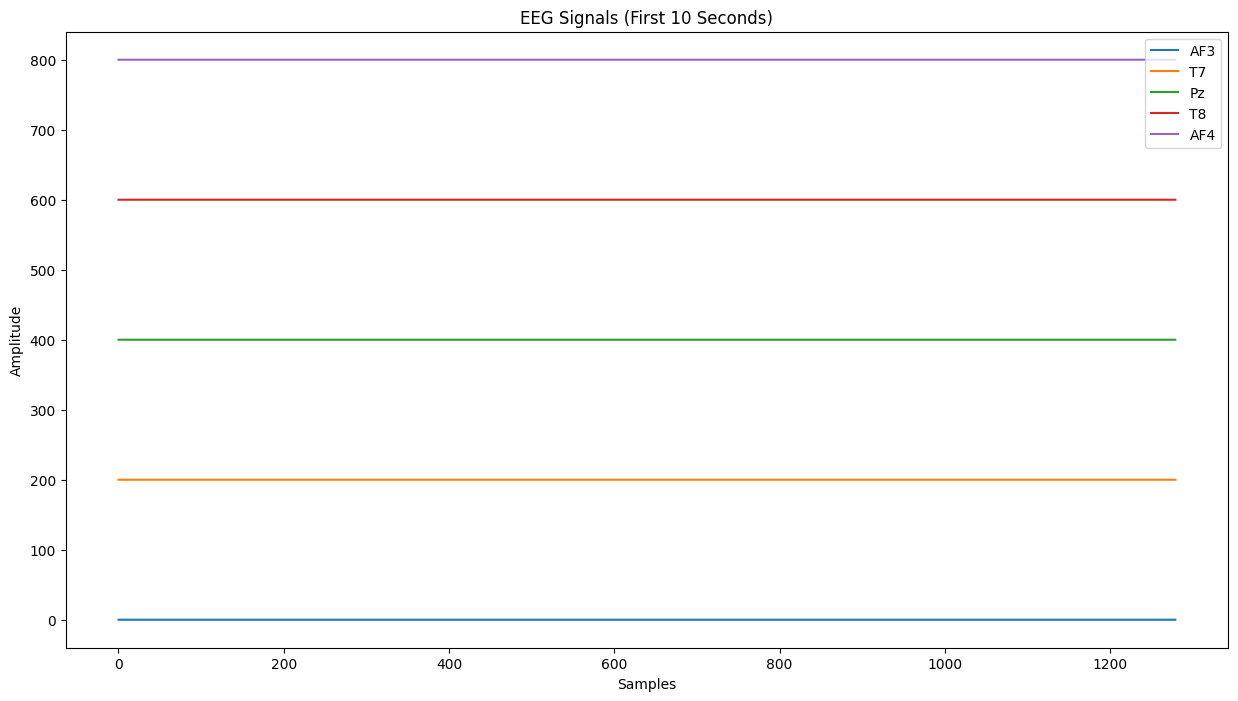

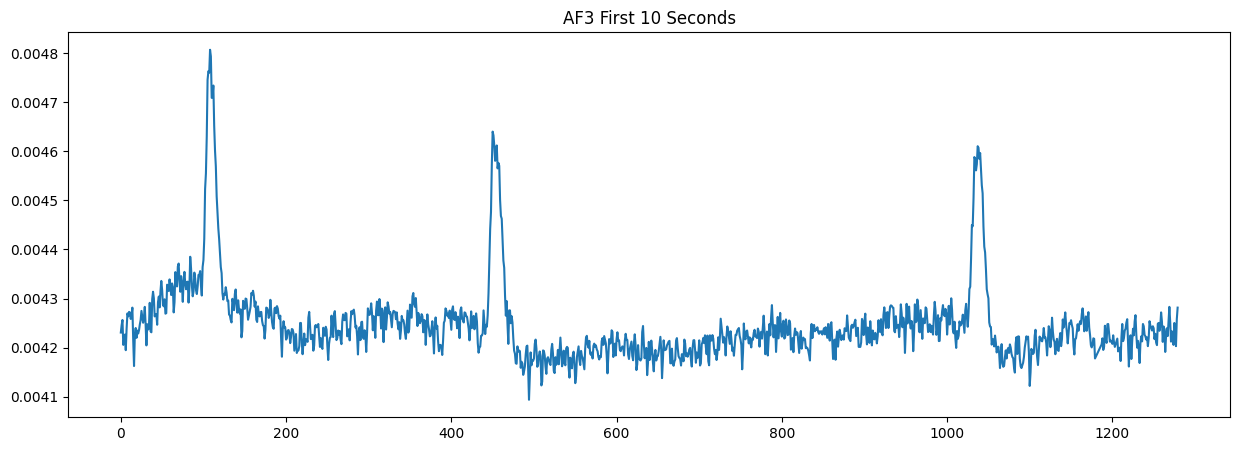

In [1]:
import mne
import matplotlib.pyplot as plt

file_path = r"C:\Users\KARTHIKEYA\Desktop\An EEG Recordings Dataset for Mental Stress Detection\Complex Mathematical Problem solving (CMPS)\1 (9).edf"

raw = mne.io.read_raw_edf(file_path, preload=True)

raw_eeg = raw.copy().pick([
    "AF3",
    "T7",
    "Pz",
    "T8",
    "AF4"
])

data = raw_eeg.get_data()

plt.figure(figsize=(15,8))

for i, ch in enumerate(raw_eeg.ch_names):
    plt.plot(data[i][:1280] + i*200, label=ch)

plt.legend()
plt.title("EEG Signals (First 10 Seconds)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()
import matplotlib.pyplot as plt

data = raw_eeg.get_data()

af3 = data[0]

plt.figure(figsize=(15,5))
plt.plot(af3[:1280])

plt.title("AF3 First 10 Seconds")
plt.show()

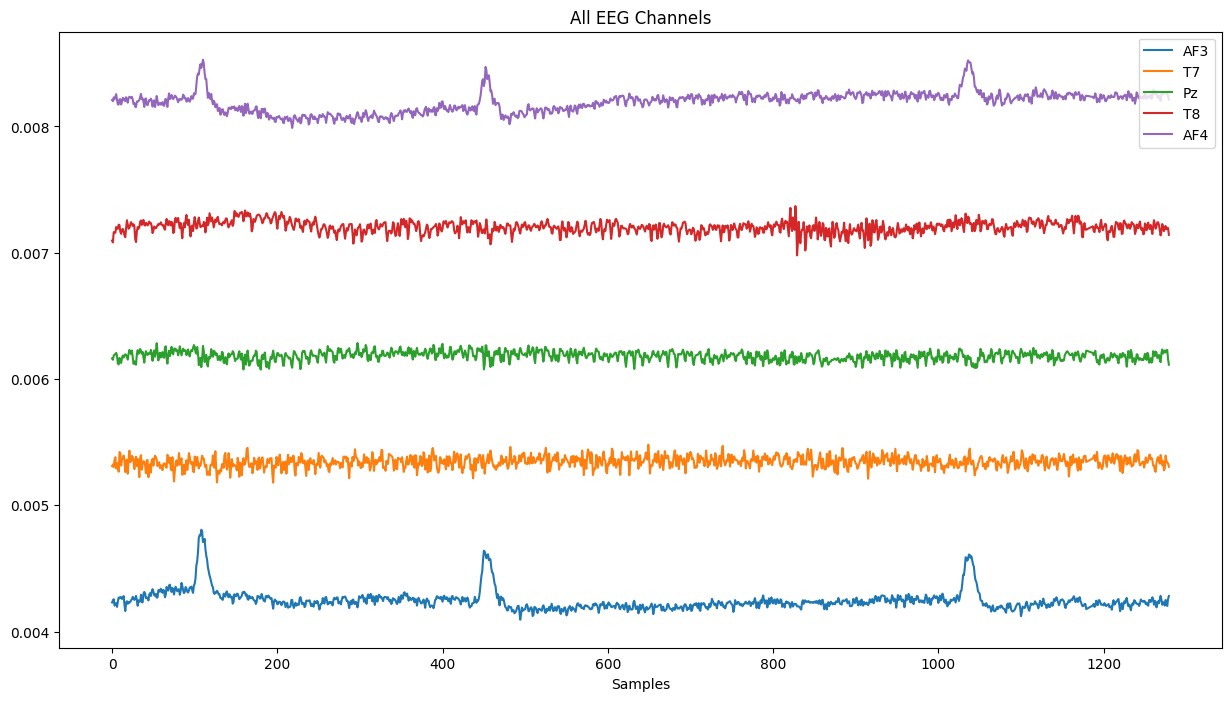

In [2]:
import matplotlib.pyplot as plt

data = raw_eeg.get_data()

plt.figure(figsize=(15,8))

offset = 0.001

for i,ch in enumerate(raw_eeg.ch_names):
    plt.plot(data[i][:1280] + i*offset,label=ch)

plt.legend()

plt.title("All EEG Channels")
plt.xlabel("Samples")

plt.show()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 845 samples (6.602 s)

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


C:\Users\KARTHIKEYA\AppData\Local\Temp\ipykernel_15512\3614778419.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot()
c:\Users\KARTHIKEYA\AppData\Local\Programs\Python\Python311\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


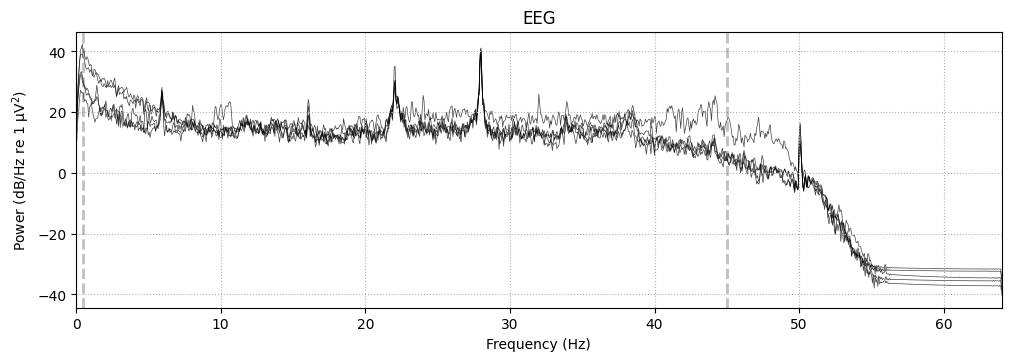

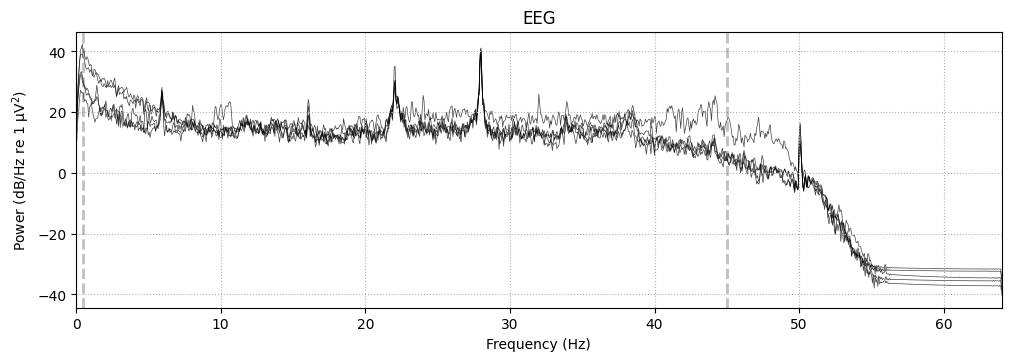

In [3]:
raw_eeg.filter(0.5,45)

psd = raw_eeg.compute_psd()

psd.plot()

In [4]:
import seaborn as sns
import pandas as pd

data = raw_eeg.get_data()

df = pd.DataFrame(
    data,
    index=raw_eeg.ch_names
)

plt.figure(figsize=(15,5))

sns.heatmap(
    df.iloc[:,0:500],
    cmap="viridis"
)

plt.title("EEG Heatmap")

plt.show()

ModuleNotFoundError: No module named 'seaborn'